# Sistema de Scoring Crediticio con Optimización de Rentabilidad Esperada


## ¿Qué características del prestatario y del préstamo permiten predecir si un préstamo terminará en incumplimiento?

## Diccionario de Variables

| Variable | Tipo | Descripción |
|---|---|---|
| **loan_amnt** | Numérica | Monto total del préstamo solicitado y aprobado por el cliente. Representa la exposición del crédito (EAD). |
| **term** | Categórica | Duración del préstamo en meses (generalmente 36 o 60 meses). |
| **int_rate** | Numérica | Tasa de interés asignada al préstamo según el riesgo del prestatario. |
| **installment** | Numérica | Pago mensual que el prestatario debe realizar durante la vida del préstamo. |
| **grade** | Categórica | Clasificación general de riesgo asignada al préstamo por LendingClub (A–G). |
| **sub_grade** | Categórica | Subclasificación más detallada dentro del grade (ejemplo: A1–G5). |
| **purpose** | Categórica | Motivo principal del préstamo (consolidación de deuda, tarjeta de crédito, negocio, etc.). |
| **home_ownership** | Categórica | Estado de propiedad de vivienda del prestatario (RENT, OWN, MORTGAGE, OTHER). |
| **annual_inc** | Numérica | Ingreso anual declarado por el prestatario. |
| **verification_status** | Categórica | Estado de verificación del ingreso del prestatario por parte de la plataforma. |
| **emp_length** | Categórica | Tiempo de empleo del prestatario expresado en años. |
| **addr_state** | Categórica | Estado de residencia del prestatario en EE.UU. |
| **dti** | Numérica | Debt-to-Income ratio. Proporción de deuda mensual frente al ingreso mensual del prestatario. |
| **revol_util** | Numérica | Porcentaje del crédito rotativo utilizado por el prestatario. |
| **revol_bal** | Numérica | Balance total utilizado en líneas de crédito rotativas. |
| **total_acc** | Numérica | Número total de cuentas de crédito registradas en el historial del prestatario. |
| **open_acc** | Numérica | Número de cuentas de crédito actualmente abiertas. |
| **fico_range_low** | Numérica | Límite inferior del rango de puntaje FICO del prestatario. |
| **fico_range_high** | Numérica | Límite superior del rango de puntaje FICO del prestatario. |
| **earliest_cr_line** | Fecha | Fecha de apertura de la primera línea de crédito del prestatario. Indica antigüedad crediticia. |
| **inq_last_6mths** | Numérica | Número de consultas de crédito realizadas en los últimos 6 meses. |
| **delinq_2yrs** | Numérica | Número de incumplimientos o atrasos en pagos en los últimos 2 años. |
| **pub_rec** | Numérica | Número de registros públicos negativos (bancarrota, gravámenes, etc.). |
| **collections_12_mths_ex_med** | Numérica | Número de cuentas enviadas a cobro en los últimos 12 meses (excluyendo facturas médicas). |
| **acc_now_delinq** | Numérica | Número de cuentas que actualmente se encuentran en mora. |
| **chargeoff_within_12_mths** | Numérica | Número de cuentas que fueron castigadas (charge-off) en los últimos 12 meses. |
| **loan_status** | Categórica | Estado actual del préstamo (Fully Paid, Charged Off, Default, Current, etc.). |
| **default** | Binaria | Variable objetivo derivada de loan_status: 1 = incumplimiento, 0 = préstamo pagado completamente. |


## Librerías y procesamiento

In [270]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
sns.set_style("whitegrid")  

In [271]:
aceptado = pd.read_csv(r"C:\Users\camil\Documents\Laburo\Portafolio\data\accepted_2007_to_2018Q4.csv\accepted_2007_to_2018Q4.csv")

C:\Users\camil\AppData\Local\Temp\ipykernel_2612\1942638441.py:1: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  aceptado = pd.read_csv(r"C:\Users\camil\Documents\Laburo\Portafolio\data\accepted_2007_to_2018Q4.csv\accepted_2007_to_2018Q4.csv")


In [272]:
selected_columns = [
    "loan_amnt",
    "term",
    "int_rate",
    "installment",
    "grade",
    "sub_grade",
    "purpose",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "emp_length",
    "addr_state",
    "dti",
    "revol_util",
    "revol_bal",
    "total_acc",
    "open_acc",
    "fico_range_low",
    "fico_range_high",
    "earliest_cr_line",
    "inq_last_6mths",
    "delinq_2yrs",
    "pub_rec",
    "collections_12_mths_ex_med",
    "acc_now_delinq",
    "chargeoff_within_12_mths",
    "loan_status"
]
aceptado = aceptado[selected_columns]

## Imputación

In [277]:
aceptado["emp_length"] = aceptado["emp_length"].fillna("Unknown")

In [278]:
aceptado.isnull().sum()

loan_amnt                       0
term                            0
int_rate                        0
installment                     0
grade                           0
sub_grade                       0
purpose                         0
home_ownership                  0
annual_inc                      4
verification_status             0
emp_length                      0
addr_state                      0
dti                           374
revol_util                    897
revol_bal                       0
total_acc                      29
open_acc                       29
fico_range_low                  0
fico_range_high                 0
earliest_cr_line               29
inq_last_6mths                 30
delinq_2yrs                    29
pub_rec                        29
collections_12_mths_ex_med    145
acc_now_delinq                 29
chargeoff_within_12_mths      145
loan_status                     0
dtype: int64

In [279]:
vars_dropna = [
    "revol_util",
    "dti",
    "chargeoff_within_12_mths",
    "collections_12_mths_ex_med",
    "inq_last_6mths",
    "total_acc",
    "acc_now_delinq",
    "pub_rec",
    "delinq_2yrs",
    "earliest_cr_line",
    "open_acc",
    "annual_inc"
]

aceptado = aceptado.dropna(subset=vars_dropna)

In [280]:
aceptado.isnull().sum()

loan_amnt                     0
term                          0
int_rate                      0
installment                   0
grade                         0
sub_grade                     0
purpose                       0
home_ownership                0
annual_inc                    0
verification_status           0
emp_length                    0
addr_state                    0
dti                           0
revol_util                    0
revol_bal                     0
total_acc                     0
open_acc                      0
fico_range_low                0
fico_range_high               0
earliest_cr_line              0
inq_last_6mths                0
delinq_2yrs                   0
pub_rec                       0
collections_12_mths_ex_med    0
acc_now_delinq                0
chargeoff_within_12_mths      0
loan_status                   0
dtype: int64

## EDA

In [273]:
aceptado.dtypes

loan_amnt                     float64
term                           object
int_rate                      float64
installment                   float64
grade                          object
sub_grade                      object
purpose                        object
home_ownership                 object
annual_inc                    float64
verification_status            object
emp_length                     object
addr_state                     object
dti                           float64
revol_util                    float64
revol_bal                     float64
total_acc                     float64
open_acc                      float64
fico_range_low                float64
fico_range_high               float64
earliest_cr_line               object
inq_last_6mths                float64
delinq_2yrs                   float64
pub_rec                       float64
collections_12_mths_ex_med    float64
acc_now_delinq                float64
chargeoff_within_12_mths      float64
loan_status 

Nos encontramos con un total de 10 variables categoricas y 17 numericas, donde nuestra variable objetivo es loan_status y es categorica por lo que nos encontramos con un problema de clasificación

In [274]:
aceptado["loan_status"].unique()

array(['Fully Paid', 'Current', 'Charged Off', 'In Grace Period',
       'Late (31-120 days)', 'Late (16-30 days)', 'Default', nan,
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

Text(0, 0.5, 'Frecuencia')

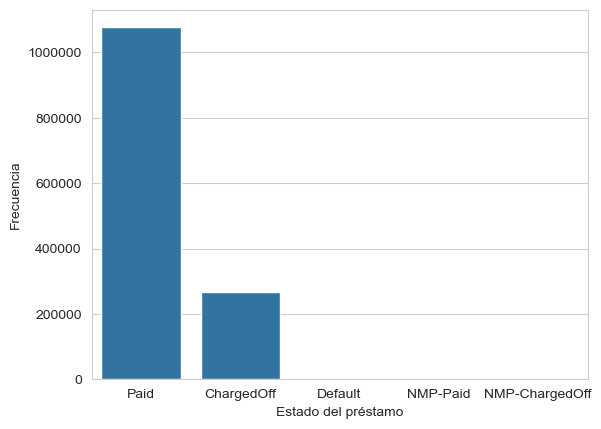

In [275]:
map_status = {
    "Fully Paid": "Paid",
    "Charged Off": "ChargedOff",
    "Default": "Default",
    "Does not meet the credit policy. Status:Fully Paid": "NMP-Paid",
    "Does not meet the credit policy. Status:Charged Off": "NMP-ChargedOff"
}

aceptado["loan_status"] = aceptado["loan_status"].replace(map_status)

aceptado = aceptado[
    aceptado["loan_status"].isin([
        "Paid",
        "ChargedOff",
        "Default",
        "NMP-Paid",
        "NMP-ChargedOff"
    ])
]


sns.countplot(x = "loan_status", data = aceptado)

plt.ticklabel_format(style='plain', axis='y')
plt.xlabel("Estado del préstamo")
plt.ylabel("Frecuencia")

In [276]:
missing_table = pd.DataFrame({
    "Valores Faltantes": aceptado.isnull().sum(),
    "Porcentaje": aceptado.isnull().mean() * 100
})

missing_table = missing_table.sort_values("Porcentaje", ascending=False)

missing_table

,Valores Faltantes,Porcentaje
emp_length,78550,5.826723
revol_util,897,0.066538
dti,374,0.027743
chargeoff_within_12_mths,145,0.010756
collections_12_mths_ex_med,145,0.010756
inq_last_6mths,30,0.002225
total_acc,29,0.002151
acc_now_delinq,29,0.002151
pub_rec,29,0.002151
delinq_2yrs,29,0.002151


La unica variable con un porcentaje mayor al 5% es emp_length por lo que podemos imputar esta variable por métodos sencillos de imputación. Para el resto de variables, no resulta necesario la imputación pues su porcentaje de valores faltantes es menor al 5%, por lo que podemos eliminar dichos registros

### Distribución

#### Préstamos

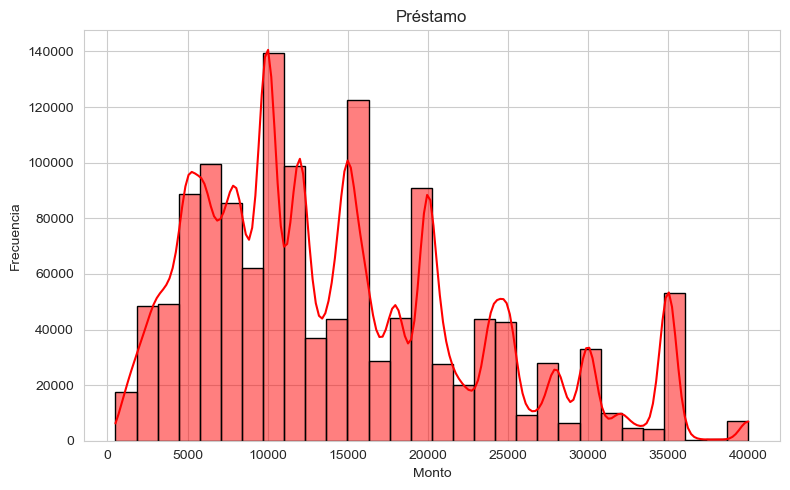

In [281]:
plt.figure(figsize=(8,5))
sns.histplot(
    aceptado["loan_amnt"],
    bins=30,
    kde = True,
    color="red",
    edgecolor="black"
)
plt.title("Préstamo")
plt.xlabel("Monto")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

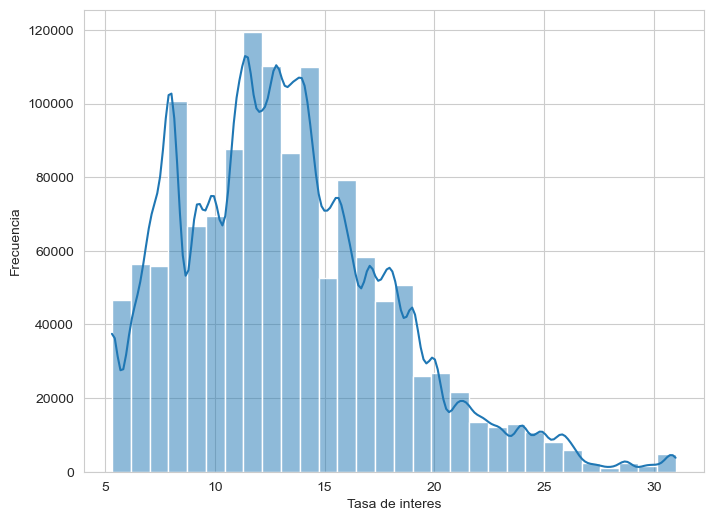

In [282]:
plt.figure(figsize=(8,6))
sns.histplot(aceptado["int_rate"],
            bins = 30,
            kde = True)
plt.xlabel("Tasa de interes")
plt.ylabel("Frecuencia")
plt.show()

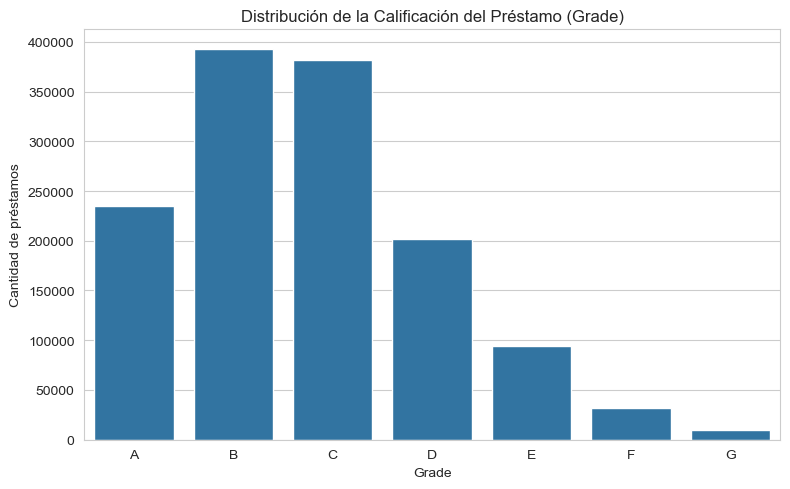

In [267]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    x="grade",
    data=aceptado,
    order=sorted(aceptado["grade"].unique())
)

plt.title("Distribución de la Calificación del Préstamo (Grade)")
plt.xlabel("Grade")
plt.ylabel("Cantidad de préstamos")

plt.ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()


#### Perfil económico del prestatario

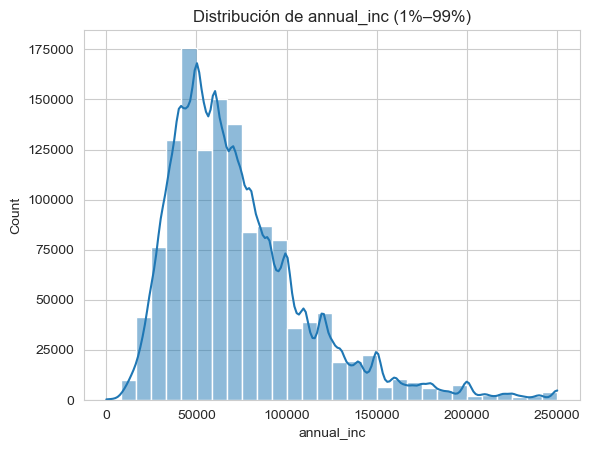

In [283]:
i = aceptado["annual_inc"]

p99 = i.quantile(0.99)

sns.histplot(i[i.between(0,p99)], bins=30, kde= True)

plt.ticklabel_format(style="plain", axis="both",)
plt.title("Distribución de annual_inc (1%–99%)")
plt.show()

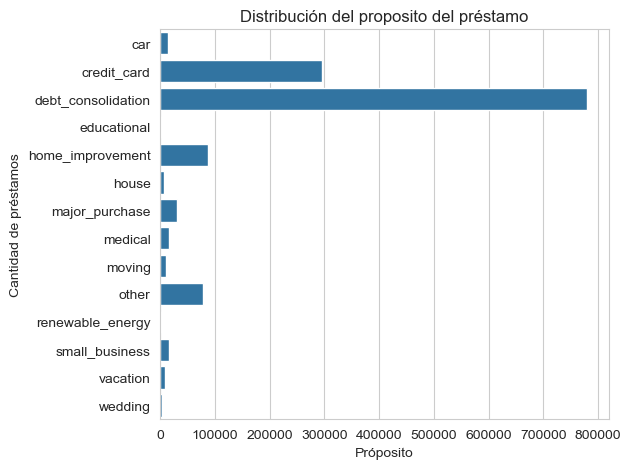

In [290]:
sns.countplot(y = aceptado["purpose"], order=sorted(aceptado["purpose"].unique()))
plt.title("Distribución del proposito del préstamo")
plt.xlabel("Próposito")
plt.ylabel("Cantidad de préstamos")
plt.tight_layout()
plt.show()

C:\Users\camil\AppData\Local\Temp\ipykernel_2612\1582950712.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


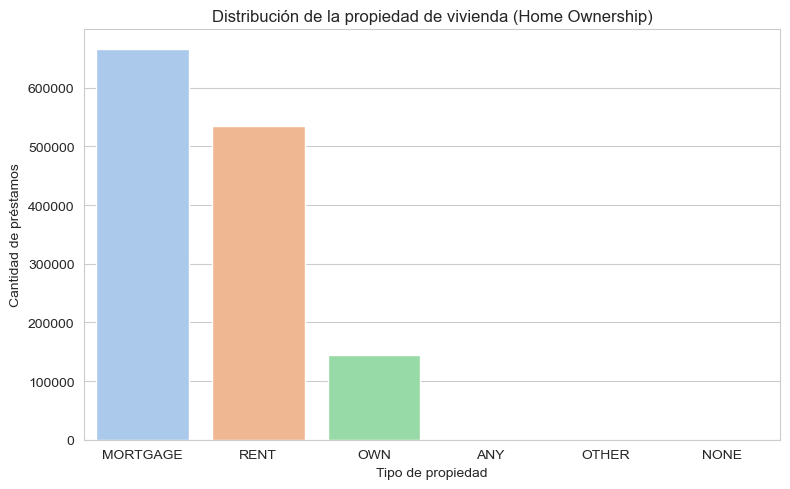

In [299]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="home_ownership",
    data=aceptado,
    order=aceptado["home_ownership"].value_counts().index,  # orden por frecuencia
    palette="pastel"
)

plt.title("Distribución de la propiedad de vivienda (Home Ownership)")
plt.xlabel("Tipo de propiedad")
plt.ylabel("Cantidad de préstamos")
plt.ticklabel_format(style="plain", axis="y")  # evita notación científica

plt.tight_layout()
plt.show()

#### Riesgo crediticio

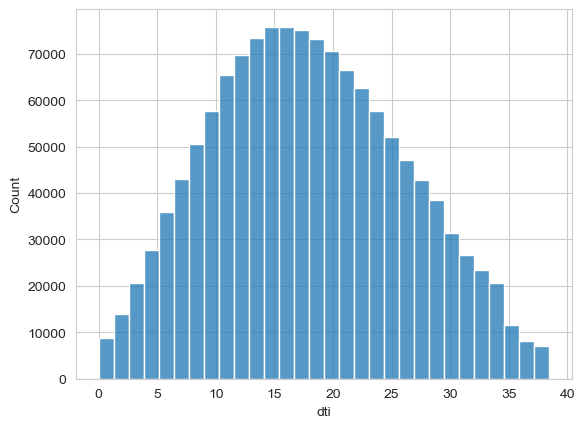

In [284]:
i1 = aceptado["dti"]

p99 = i1.quantile(0.99)

sns.histplot(i1[i1.between(0, p99)], bins=30)
plt.ticklabel_format(style="plain")
plt.show()

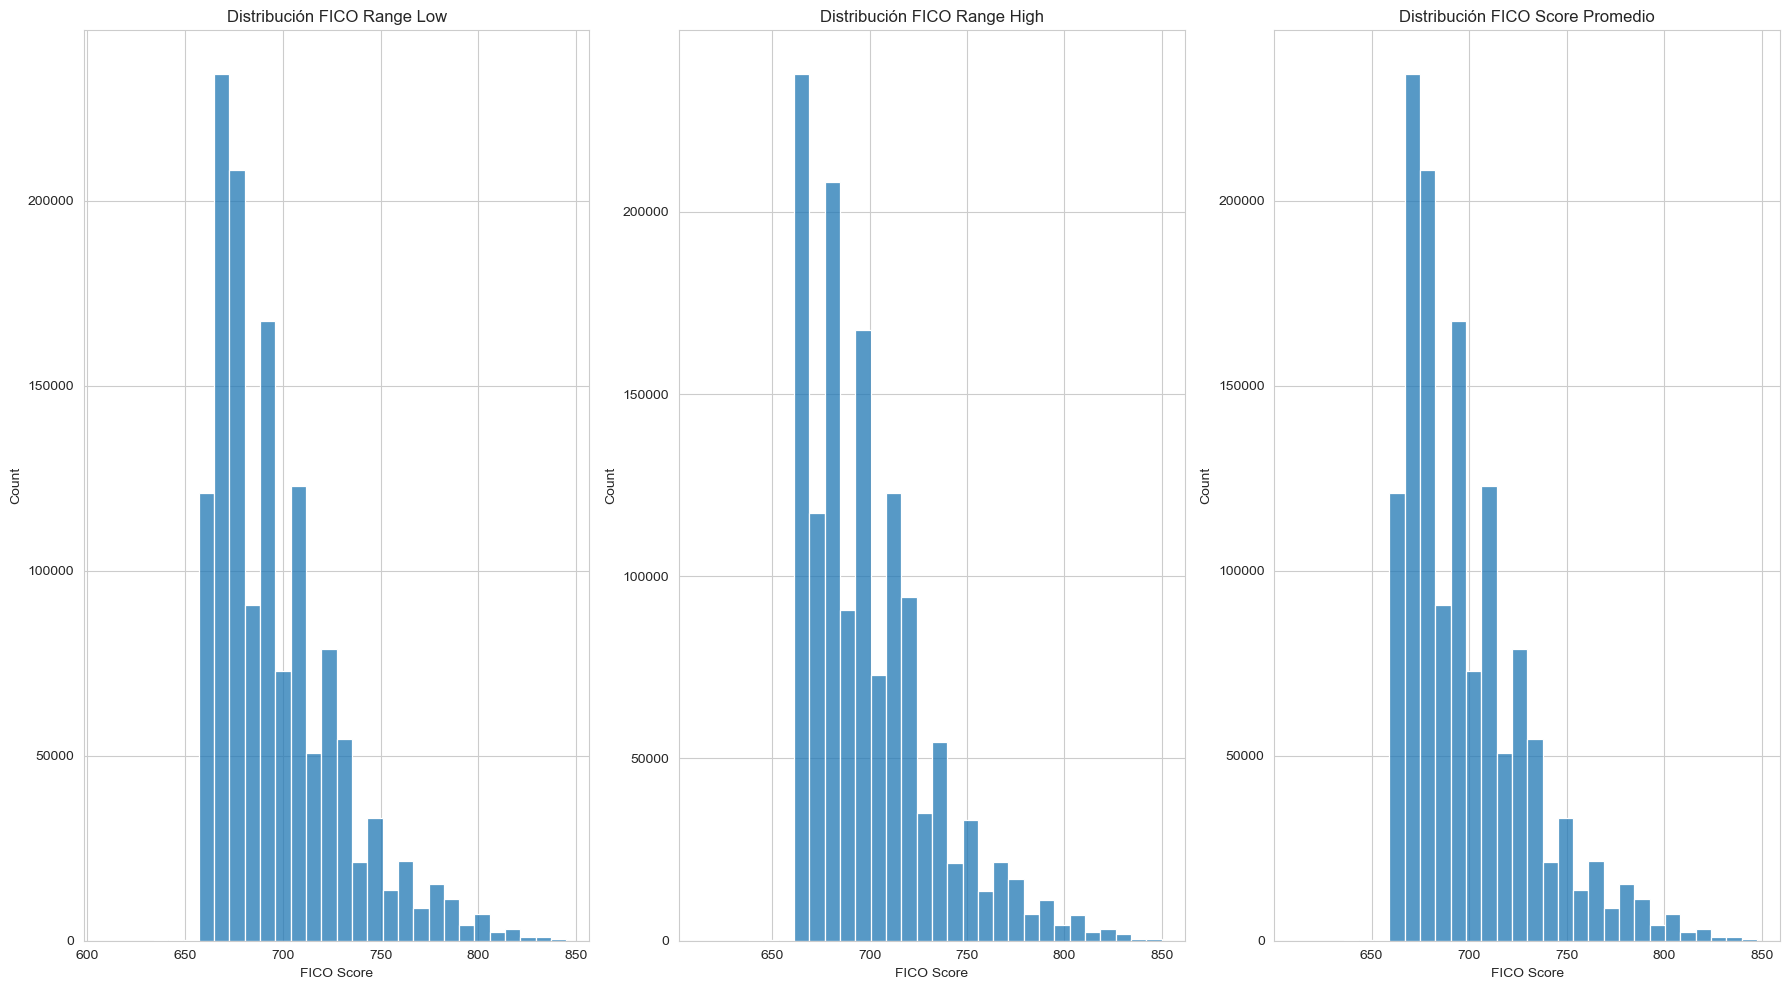

In [ ]:
aceptado["fico_score"] = (
    aceptado["fico_range_low"] + aceptado["fico_range_high"]
) / 2
# FICO rango inferior

fig, axes = plt.subplots(1, 3, figsize=(18,10))
sns.histplot(aceptado["fico_range_low"],bins= 30, ax=axes[0])
axes[0].set_title("Distribución FICO Range Low")
axes[0].set_xlabel("FICO Score")

# FICO rango superior
sns.histplot(aceptado["fico_range_high"],bins= 30, ax=axes[1])
axes[1].set_title("Distribución FICO Range High")
axes[1].set_xlabel("FICO Score")

# FICO promedio
sns.histplot(aceptado["fico_score"], bins= 30, ax=axes[2])
axes[2].set_title("Distribución FICO Score Promedio")
axes[2].set_xlabel("FICO Score")

plt.tight_layout()
plt.show()

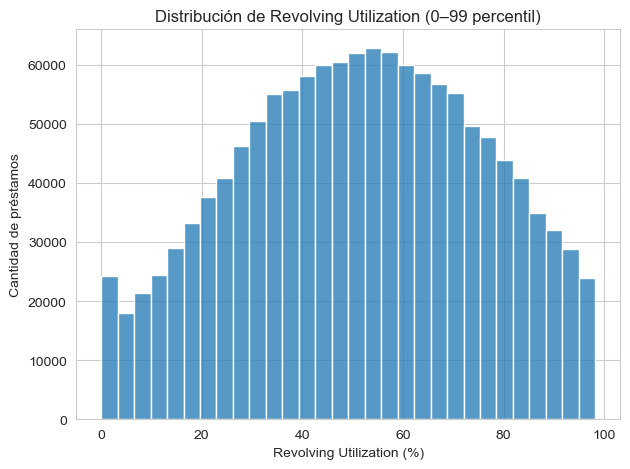

In [296]:
i0 = aceptado["revol_util"]
p099= i0.quantile(0.99)
sns.histplot(i0[i0.between(0, p099)], bins=30)

plt.xlabel("Revolving Utilization (%)")  # etiqueta del eje x
plt.ylabel("Cantidad de préstamos")      # etiqueta del eje y
plt.title("Distribución de Revolving Utilization (0–99 percentil)")

plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()



### Relación con el estado del préstamo

In [321]:
import pandas as pd

# Crear la nueva columna con las 3 categorías
aceptado["target"] = aceptado["loan_status"].replace({
    "Paid": "Pagado",
    "NMP-Paid": "Pagado",
    "ChargedOff": "Incumplimiento",
    "NMP-ChargedOff": "Incumplimiento",
    "Default": "Incumplimiento"
})

# Verificar el conteo de cada categoría
conteo = aceptado["target"].value_counts()
print(conteo)

target
Pagado            1077635
Incumplimiento     269080
Name: count, dtype: int64


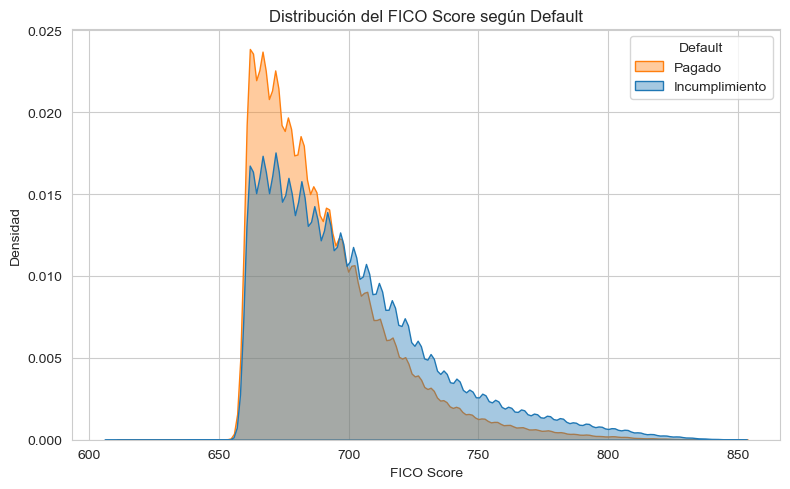

In [325]:

plt.figure(figsize=(8,5))

sns.kdeplot(
    data=aceptado,
    x="fico_score",
    hue="target",
    common_norm= False,
    fill=True,
    alpha=0.4
)

plt.ticklabel_format(style="plain", axis="y")
plt.title("Distribución del FICO Score según Default")
plt.xlabel("FICO Score")
plt.ylabel("Densidad")
plt.legend(title="Default", labels=["Pagado", "Incumplimiento"])
plt.tight_layout()
plt.show()

   - fico vs default
   - dti vs default
   - grade vs default

C:\Users\camil\AppData\Local\Temp\ipykernel_2612\2923875280.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


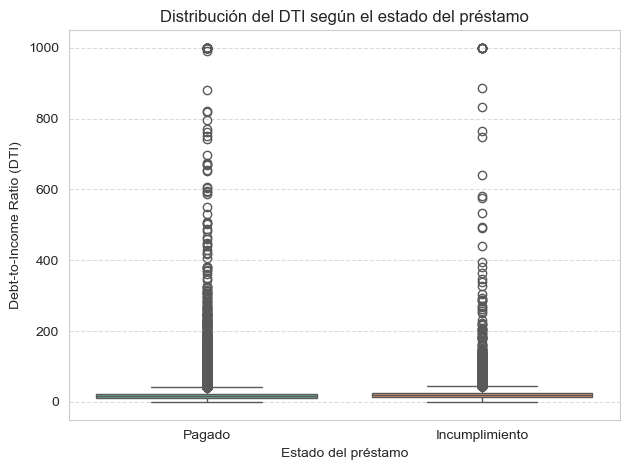

In [ ]:
sns.boxplot(
    x="target",
    y="dti",
    data=aceptado,
    palette="Set2"
)

plt.title("Distribución del DTI según el estado del préstamo")
plt.xlabel("Estado del préstamo")
plt.ylabel("Debt-to-Income Ratio (DTI)")
plt.ylim(0, p99*1.05)  # ajusta un poco arriba para que no corte el bigote
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()